## Importing Libraries

Pandas will be used for data manipulation and analysis, while Matplotlib will be used for data visualization.

In [394]:
import pandas as pd
import matplotlib.pyplot as plt

## Loading the Dataset
The target variable is `Churn`, which indicates whether a customer has left the service or not.

In [395]:
df=pd.read_csv("customer_churn.csv")

In [396]:
df.head()

,CustomerID,Gender,Age,Tenure_Months,Contract,Internet_Service,Payment_Method,Monthly_Charges,Total_Charges,Support_Calls,Satisfaction_Score,Services_Count,Churn
0,CUST10001,Male,22,9,Month-to-month,DSL,Mailed check,115.77,1000.98,0,1.0,6,No
1,CUST10002,Male,59,47,Month-to-month,No,Credit card,135.23,6244.89,4,4.0,1,No
2,CUST10003,Male,52,70,Month-to-month,Fiber optic,Electronic check,139.74,9748.54,5,1.0,5,Yes
3,CUST10004,Male,41,63,Month-to-month,Fiber optic,Mailed check,85.47,5418.57,1,1.0,4,No
4,CUST10005,Female,40,20,One year,DSL,Credit card,87.64,1734.99,2,4.0,4,No


## Dataset Dimensions

In [397]:
df.shape

(503, 13)

## Dataset columns

In [398]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Tenure_Months', 'Contract',
       'Internet_Service', 'Payment_Method', 'Monthly_Charges',
       'Total_Charges', 'Support_Calls', 'Satisfaction_Score',
       'Services_Count', 'Churn'],
      dtype='object')

## Dataset Information
The `info()` method helps us understand the data types and the number of non-null values in each column.

In [399]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          503 non-null    object 
 1   Gender              503 non-null    object 
 2   Age                 503 non-null    int64  
 3   Tenure_Months       503 non-null    int64  
 4   Contract            503 non-null    object 
 5   Internet_Service    503 non-null    object 
 6   Payment_Method      503 non-null    object 
 7   Monthly_Charges     503 non-null    float64
 8   Total_Charges       493 non-null    float64
 9   Support_Calls       503 non-null    int64  
 10  Satisfaction_Score  496 non-null    float64
 11  Services_Count      503 non-null    int64  
 12  Churn               503 non-null    object 
dtypes: float64(3), int64(4), object(6)
memory usage: 51.2+ KB


## Statistical Summary

In [400]:
df.describe()

,Age,Tenure_Months,Monthly_Charges,Total_Charges,Support_Calls,Satisfaction_Score,Services_Count
count,503.000000,503.000000,503.000000,493.000000,503.000000,496.000000,503.000000
mean,44.009940,36.934394,85.000815,3182.792454,2.178926,3.000000,3.574553
std,15.130044,20.982389,38.543146,2434.787017,1.538287,1.418493,1.714105
min,18.000000,1.000000,20.160000,0.000000,0.000000,1.000000,1.000000
25%,31.000000,18.000000,51.675000,1198.590000,1.000000,2.000000,2.000000
50%,44.000000,38.000000,84.240000,2560.970000,2.000000,3.000000,4.000000
75%,57.000000,56.000000,119.670000,4825.540000,3.000000,4.000000,5.000000
max,70.000000,72.000000,149.840000,10606.540000,7.000000,5.000000,6.000000


## Data Types

Let's identify which variables are numerical and which are categorical.

In [401]:
df.dtypes

CustomerID             object
Gender                 object
Age                     int64
Tenure_Months           int64
Contract               object
Internet_Service       object
Payment_Method         object
Monthly_Charges       float64
Total_Charges         float64
Support_Calls           int64
Satisfaction_Score    float64
Services_Count          int64
Churn                  object
dtype: object

In [402]:
# Numerical Columns
df.select_dtypes(include="number").columns

Index(['Age', 'Tenure_Months', 'Monthly_Charges', 'Total_Charges',
       'Support_Calls', 'Satisfaction_Score', 'Services_Count'],
      dtype='object')

In [403]:
# Categorical Columns
df.select_dtypes(include="object").columns

Index(['CustomerID', 'Gender', 'Contract', 'Internet_Service',
       'Payment_Method', 'Churn'],
      dtype='object')

## Checking Missing Values

In [404]:
df.isnull().sum()

CustomerID             0
Gender                 0
Age                    0
Tenure_Months          0
Contract               0
Internet_Service       0
Payment_Method         0
Monthly_Charges        0
Total_Charges         10
Support_Calls          0
Satisfaction_Score     7
Services_Count         0
Churn                  0
dtype: int64

## Checking Duplicate Records

In [405]:
df.duplicated().sum()

np.int64(3)

## Understanding the Target Variable
The target variable in this project is `Churn`.


In [406]:
df["Churn"].value_counts()

Churn
No     435
Yes     68
Name: count, dtype: int64

In [407]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     86.481113
Yes    13.518887
Name: proportion, dtype: float64

## Customer Churn Distribution

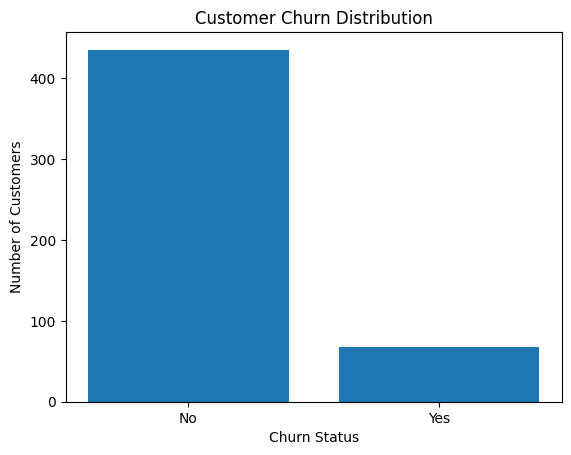

In [408]:
churn = df["Churn"].value_counts()
plt.bar(churn.index, churn.values)
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.show()

## Age Distribution
This histogram shows the distribution of customer ages in the dataset.

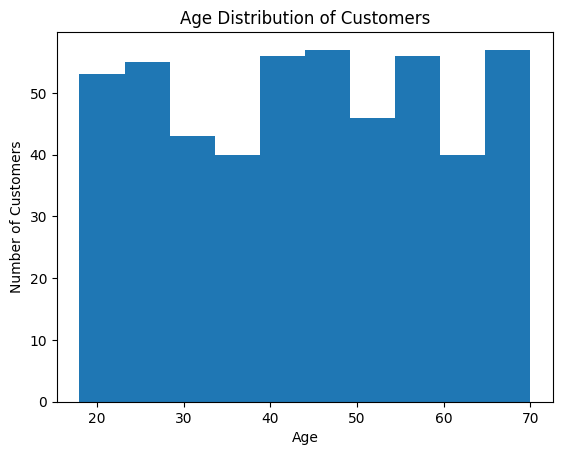

In [409]:
plt.hist(df["Age"], bins=10)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution of Customers")
plt.show()

## Monthly Charges Distribution

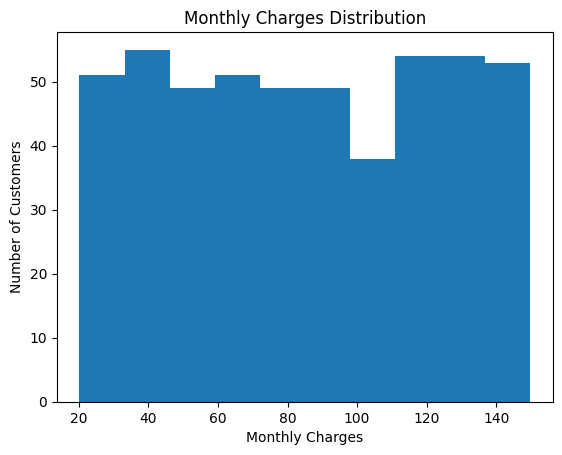

In [410]:
plt.hist(df["Monthly_Charges"], bins=10)
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Monthly Charges Distribution")
plt.show()

## Customer Tenure Distribution

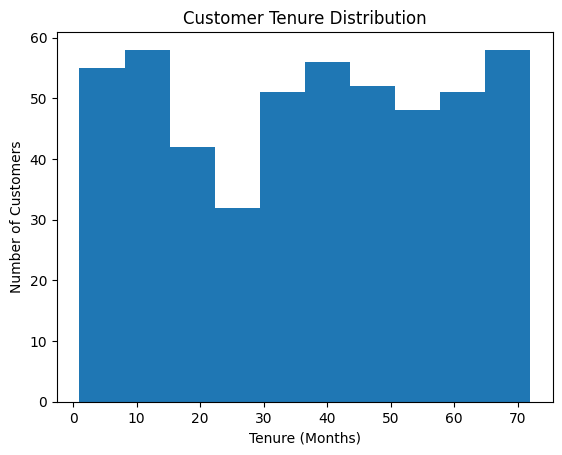

In [411]:
plt.hist(df["Tenure_Months"], bins=10)
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.title("Customer Tenure Distribution")
plt.show()

## Relationship Between Customer Tenure and Monthly Charges
This scatter plot helps visualize the relationship between customer tenure and monthly charges.

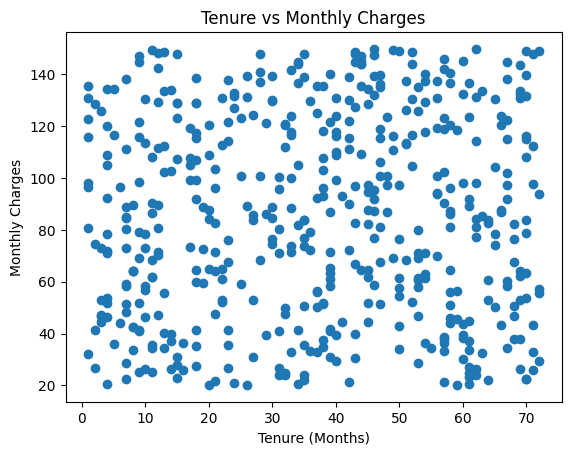

In [412]:
plt.scatter(df["Tenure_Months"], df["Monthly_Charges"])
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.title("Tenure vs Monthly Charges")
plt.show()

## Customer Distribution by Contract Type

This bar chart shows the number of customers under each contract type.

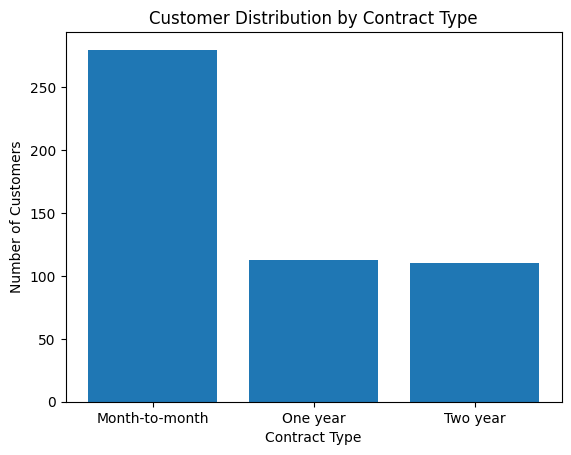

In [413]:
contract = df["Contract"].value_counts()
plt.bar(contract.index, contract.values)
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Contract Type")
plt.show()

### Observation

The dataset contains the highest number of customers with month-to-month contracts, while one-year and two-year contracts have fewer customers.

## Customer Distribution by Internet Service

This bar chart shows the number of customers using each type of internet service.

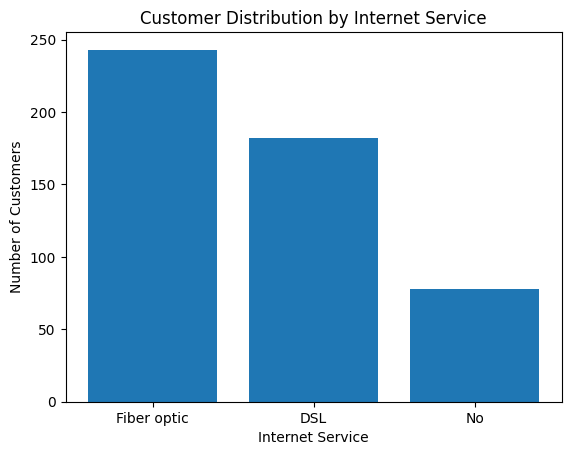

In [414]:
internet = df["Internet_Service"].value_counts()
plt.bar(internet.index, internet.values)
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Internet Service")
plt.show()

## Customer Distribution by Payment Method

This bar chart shows the number of customers using each payment method.

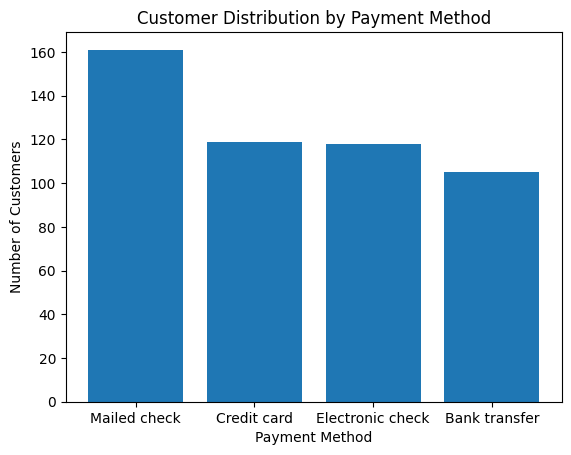

In [415]:
payment = df["Payment_Method"].value_counts()
plt.bar(payment.index, payment.values)
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Payment Method")
plt.show()